In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [66]:
current_dir = Path.cwd()
file_path = current_dir.parent.parent / 'Datasets' / 'Classification datasets' / 'Heart Disease' / 'heart.csv'

df = pd.read_csv(file_path)

df.sample(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
941,52,0,2,136,196,0,0,169,0,0.1,1,0,2,1
751,65,0,2,160,360,0,0,151,0,0.8,2,0,2,1
618,49,1,1,130,266,0,1,171,0,0.6,2,0,2,1
36,51,1,3,125,213,0,0,125,1,1.4,2,1,2,1
233,41,0,1,126,306,0,1,163,0,0.0,2,0,2,1
75,47,1,2,138,257,0,0,156,0,0.0,2,0,2,1
865,60,0,3,150,240,0,1,171,0,0.9,2,0,2,1
978,44,1,0,110,197,0,0,177,0,0.0,2,1,2,0
882,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
794,61,1,3,134,234,0,1,145,0,2.6,1,2,2,0


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [68]:
df.duplicated().sum()

np.int64(723)

In [69]:
df = df.drop_duplicates()

In [70]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

<Axes: xlabel='trestbps', ylabel='Count'>

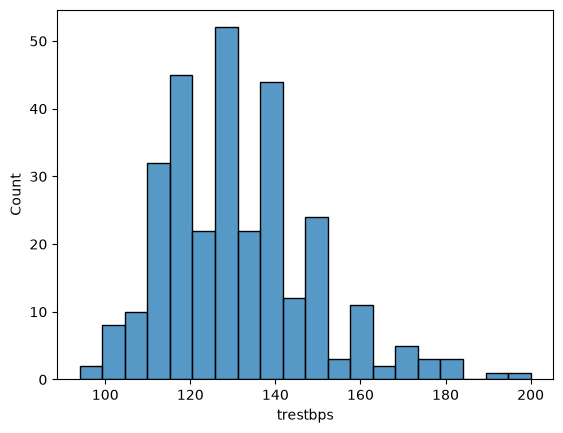

In [71]:
sns.histplot(
    data=df,
    x='trestbps',
    bins=20
)

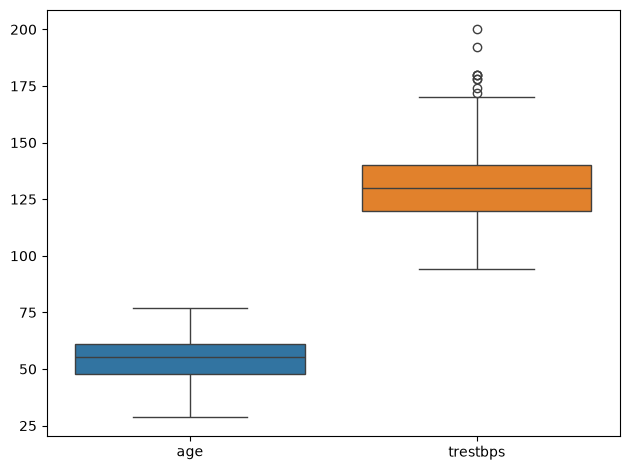

In [72]:


sns.boxplot(data=df[['age', 'trestbps']])
plt.tight_layout()

In [73]:
X = df.drop('target', axis=1)
y = df['target']
X.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
495,59,1,0,135,234,0,1,161,0,0.5,1,0,3
68,37,0,2,120,215,0,1,170,0,0.0,2,0,2
123,65,0,2,140,417,1,0,157,0,0.8,2,1,2
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2
279,41,0,1,105,198,0,1,168,0,0.0,2,1,2


In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.25)

X_train.sample(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
20,60,1,2,140,185,0,0,155,0,3.0,1,0,2
691,55,0,1,135,250,0,0,161,0,1.4,1,0,2
288,58,0,2,120,340,0,1,172,0,0.0,2,0,2
224,51,1,0,140,261,0,0,186,1,0.0,2,0,2
570,54,0,2,135,304,1,1,170,0,0.0,2,0,2


In [75]:
from sklearn.preprocessing import StandardScaler

heart_scaler = StandardScaler()

X_train_scaled = heart_scaler.fit_transform(X_train)
X_test_scaled = heart_scaler.transform(X_test)

X_train_scaled

array([[-1.2296696 ,  0.68376346, -0.98771593, ..., -0.73356553,
        -0.70070755, -0.54435314],
       [ 0.07454   ,  0.68376346, -0.01717767, ...,  0.97556653,
        -0.70070755, -0.54435314],
       [-2.09914268,  0.68376346, -0.01717767, ...,  0.97556653,
        -0.70070755, -0.54435314],
       ...,
       [ 0.61796067, -1.46249406,  1.92389886, ...,  0.97556653,
        -0.70070755, -0.54435314],
       [ 1.37874961, -1.46249406,  0.9533606 , ...,  0.97556653,
         0.27082562, -0.54435314],
       [-1.33835374,  0.68376346, -0.01717767, ...,  0.97556653,
        -0.70070755, -0.54435314]], shape=(226, 13))

In [76]:
import pickle

current_dir = Path.cwd()
file_path = current_dir.parent.parent / 'ML_Models' / 'Scalers' / 'heart_scaler.pkl'

pickle.dump(heart_scaler, open(file_path, 'wb'))

## Training Defferent types of models and evaluation

In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier 

In [116]:
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score

In [117]:
## Logistic Regression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics:\n{confusion_matrix(y_test, y_pred)}')

print(f'accuracy score:{accuracy_score(y_test, y_pred)}')
print(f'recall score: {recall_score(y_test, y_pred)}')
print(f'f1_score: {f1_score(y_test, y_pred)}')

Confusion Metrics:
[[27 13]
 [ 4 32]]
accuracy score:0.7763157894736842
recall score: 0.8888888888888888
f1_score: 0.7901234567901234


In [80]:
param_grid = {
    'C': [1,2,3,4,5],
    'fit_intercept': [True, False],
}

In [81]:
# Using GridSearchCv

grid = GridSearchCV(LogisticRegression(), param_grid=param_grid, n_jobs=5, cv=5, )

grid.fit(X_train_scaled, y_train)
grid.best_params_

{'C': 2, 'fit_intercept': True}

In [118]:
model = LogisticRegression(C=2, fit_intercept=True)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics:\n{confusion_matrix(y_test, y_pred)}')
print(f'accuracy score:{accuracy_score(y_test, y_pred)}')
print(f'recall score: {recall_score(y_test, y_pred)}')
print(f'f1_score: {f1_score(y_test, y_pred)}')

Confusion Metrics:
[[27 13]
 [ 4 32]]
accuracy score:0.7763157894736842
recall score: 0.8888888888888888
f1_score: 0.7901234567901234


In [92]:
file_path = Path.cwd().parent.parent/ 'ML_models and scalers' / 'ML_Models'/'Heart'/'Logistic_model.pkl'
pickle.dump(model, open(file_path, 'wb'))

In [119]:
# kNN

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics:\n{confusion_matrix(y_test, y_pred)}')
print(f'accuracy score:{accuracy_score(y_test, y_pred)}')
print(f'recall score: {recall_score(y_test, y_pred)}')
print(f'f1_score: {f1_score(y_test, y_pred)}')

Confusion Metrics:
[[28 12]
 [ 8 28]]
accuracy score:0.7368421052631579
recall score: 0.7777777777777778
f1_score: 0.7368421052631579


In [121]:
param_grid = {
    'n_neighbors':[3,5,7,9,11,13,15,17],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
}

In [122]:
## Using GridSearchCV

grid = GridSearchCV(KNeighborsClassifier(n_jobs=-1), param_grid=param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
grid.best_params_

{'algorithm': 'auto', 'n_neighbors': 17, 'weights': 'distance'}

In [120]:

model = KNeighborsClassifier(algorithm='auto', n_neighbors=15, weights='distance')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics:\n{confusion_matrix(y_test, y_pred)}')
print(f'accuracy score:{accuracy_score(y_test, y_pred)}')
print(f'recall score: {recall_score(y_test, y_pred)}')
print(f'f1_score: {f1_score(y_test, y_pred)}')

Confusion Metrics:
[[26 14]
 [ 2 34]]
accuracy score:0.7894736842105263
recall score: 0.9444444444444444
f1_score: 0.8095238095238095


In [93]:
file_path = Path.cwd().parent.parent/ 'ML_models and scalers' / 'ML_Models'/'Heart'/'kNN_model.pkl'
pickle.dump(model, open(file_path, 'wb'))

In [123]:
# Support vector classifier
model = SVC()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics:\n{confusion_matrix(y_test, y_pred)}')
print(f'accuracy score:{accuracy_score(y_test, y_pred)}')
print(f'recall score: {recall_score(y_test, y_pred)}')
print(f'f1_score: {f1_score(y_test, y_pred)}')

Confusion Metrics:
[[28 12]
 [ 5 31]]
accuracy score:0.7763157894736842
recall score: 0.8611111111111112
f1_score: 0.7848101265822784


In [95]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 2, 5],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto'],
}

In [96]:
grid = GridSearchCV(SVC(), param_grid=param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
print(grid.best_params_)


{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [124]:
model = SVC(C=1, gamma='scale', kernel='linear')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics:\n{confusion_matrix(y_test, y_pred)}')
print(f'accuracy score:{accuracy_score(y_test, y_pred)}')
print(f'recall score: {recall_score(y_test, y_pred)}')
print(f'f1_score: {f1_score(y_test, y_pred)}')

Confusion Metrics:
[[27 13]
 [ 6 30]]
accuracy score:0.75
recall score: 0.8333333333333334
f1_score: 0.759493670886076


In [100]:
file_path = Path.cwd().parent.parent/ 'ML_models and scalers' / 'ML_Models'/'Heart'/'svc_model.pkl'
pickle.dump(model, open(file_path, 'wb'))

In [125]:
## Decision Tree

model = DecisionTreeClassifier()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics:\n{confusion_matrix(y_test, y_pred)}')
print(f'accuracy_score:{accuracy_score(y_test, y_pred)}')
print(f'recall_score: {recall_score(y_test, y_pred)}')
print(f'f1_score: {f1_score(y_test, y_pred)}')


Confusion Metrics:
[[30 10]
 [12 24]]
accuracy_score:0.7105263157894737
recall_score: 0.6666666666666666
f1_score: 0.6857142857142857


In [109]:
file_path = Path.cwd().parent.parent/ 'ML_models and scalers' / 'ML_Models'/'Heart'/'tree_model.pkl'
pickle.dump(model, open(file_path, 'wb'))

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [3,4,5,6,7,8],
    'min_samples_split': [4,6,8,10,15],
}

In [106]:
grid = GridSearchCV(DecisionTreeClassifier(), param_grid=param_grid, cv=5)
grid.fit(X_train_scaled, y_train)
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 7,
 'min_samples_split': 15,
 'splitter': 'random'}

In [126]:
model = DecisionTreeClassifier(criterion='entropy', max_depth=7, min_samples_split=15, splitter='random')
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(f'Confusion Metrics:\n{confusion_matrix(y_test, y_pred)}')
print(f'accuracy_score:{accuracy_score(y_test, y_pred)}')
print(f'recall_score: {recall_score(y_test, y_pred)}')
print(f'f1_score: {f1_score(y_test, y_pred)}')


Confusion Metrics:
[[27 13]
 [ 4 32]]
accuracy_score:0.7763157894736842
recall_score: 0.8888888888888888
f1_score: 0.7901234567901234


In [115]:
df.sample(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
234,49,0,0,130,269,0,1,163,0,0.0,2,0,2,1
49,60,1,0,117,230,1,1,160,1,1.4,2,2,3,0
334,60,1,0,130,206,0,0,132,1,2.4,1,2,3,0
18,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
282,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
254,35,1,0,120,198,0,1,130,1,1.6,1,0,3,0
376,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
177,64,1,0,120,246,0,0,96,1,2.2,0,1,2,0
286,64,0,2,140,313,0,1,133,0,0.2,2,0,3,1
694,39,1,0,118,219,0,1,140,0,1.2,1,0,3,0
